In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/nav_data.csv")

df["daily_return"] = df["nav"].pct_change()

df.head()

,date,nav,daily_return
0,2013-01-02,103.0059,NaN
1,2013-01-03,103.0306,0.000240
2,2013-01-04,103.0619,0.000304
3,2013-01-07,103.1408,0.000766
4,2013-01-08,103.1663,0.000247


In [3]:
sharpe = (df["daily_return"].mean() /
          df["daily_return"].std()) * np.sqrt(252)

volatility = df["daily_return"].std() * np.sqrt(252)

print("Sharpe Ratio:", sharpe)
print("Volatility:", volatility)

Sharpe Ratio: 0.05954004603567517
Volatility: 0.08716380633047063


In [4]:
var95 = df["daily_return"].quantile(0.05)

print("95% Value at Risk:", var95)

95% Value at Risk: -0.0010240332021842823


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

In [2]:
nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

perf = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")

In [3]:
nav['date'] = pd.to_datetime(nav['date'])

In [4]:
nav = nav.sort_values(by=['amfi_code', 'date'])

nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

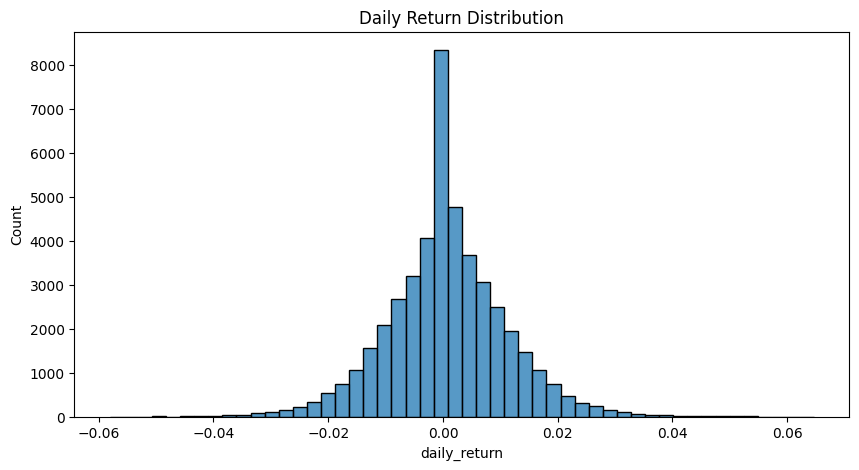

In [5]:
plt.figure(figsize=(10,5))

sns.histplot(nav['daily_return'].dropna(), bins=50)

plt.title("Daily Return Distribution")

plt.show()

In [6]:
cagr_list = []

for code in nav['amfi_code'].unique():

    df = nav[nav['amfi_code'] == code]

    start_nav = df.iloc[0]['nav']
    end_nav = df.iloc[-1]['nav']

    years = 5

    cagr = ((end_nav / start_nav) ** (1/years)) - 1

    cagr_list.append([code, cagr])

cagr_df = pd.DataFrame(cagr_list, columns=['amfi_code', 'cagr_5yr'])

print(cagr_df.head())

   amfi_code  cagr_5yr
0     100016  0.023168
1     100025  0.039127
2     100033  0.260741
3     101206  0.204427
4     101207  0.069533


In [7]:
rf = 0.065

sharpe_list = []

for code in nav['amfi_code'].unique():

    df = nav[nav['amfi_code'] == code]

    mean_return = df['daily_return'].mean() * 252

    std_return = df['daily_return'].std() * np.sqrt(252)

    sharpe = (mean_return - rf) / std_return

    sharpe_list.append([code, sharpe])

sharpe_df = pd.DataFrame(sharpe_list, columns=['amfi_code', 'sharpe_ratio'])

print(sharpe_df.head())

   amfi_code  sharpe_ratio
0     100016     -0.201517
1     100025     -0.567095
2     100033      1.093699
3     101206      1.027213
4     101207      0.162661


In [8]:
sortino_list = []

for code in nav['amfi_code'].unique():

    df = nav[nav['amfi_code'] == code]

    downside = df[df['daily_return'] < 0]['daily_return']

    downside_std = downside.std() * np.sqrt(252)

    mean_return = df['daily_return'].mean() * 252

    sortino = (mean_return - rf) / downside_std

    sortino_list.append([code, sortino])

sortino_df = pd.DataFrame(sortino_list, columns=['amfi_code', 'sortino_ratio'])

print(sortino_df.head())

   amfi_code  sortino_ratio
0     100016      -0.351047
1     100025      -0.941821
2     100033       1.829134
3     101206       1.799563
4     101207       0.276644


In [9]:
benchmark = nav.groupby('date')['daily_return'].mean().reset_index()

benchmark.columns = ['date', 'benchmark_return']

In [10]:
alpha_beta = []

for code in nav['amfi_code'].unique():

    fund = nav[nav['amfi_code'] == code]

    merged = pd.merge(
        fund,
        benchmark,
        on='date'
    )

    merged = merged.dropna()

    slope, intercept, r, p, se = linregress(
        merged['benchmark_return'],
        merged['daily_return']
    )

    alpha = intercept * 252
    beta = slope

    alpha_beta.append([code, alpha, beta])

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=['amfi_code', 'alpha', 'beta']
)

print(alpha_beta_df.head())

   amfi_code     alpha      beta
0     100016 -0.089699  0.788441
1     100025  0.033199  0.060713
2     100033  0.114423  0.991590
3     101206  0.097443  0.737015
4     101207 -0.350741  2.878184


In [11]:
mdd_list = []

for code in nav['amfi_code'].unique():

    df = nav[nav['amfi_code'] == code].copy()

    df['running_max'] = df['nav'].cummax()

    df['drawdown'] = (df['nav'] / df['running_max']) - 1

    mdd = df['drawdown'].min()

    mdd_list.append([code, mdd])

mdd_df = pd.DataFrame(
    mdd_list,
    columns=['amfi_code', 'max_drawdown']
)

print(mdd_df.head())

   amfi_code  max_drawdown
0     100016     -0.247344
1     100025     -0.043083
2     100033     -0.162172
3     101206     -0.112916
4     101207     -0.354469


In [12]:
score = cagr_df.merge(sharpe_df, on='amfi_code')

score = score.merge(alpha_beta_df, on='amfi_code')

score = score.merge(mdd_df, on='amfi_code')

In [13]:
score['return_rank'] = score['cagr_5yr'].rank(ascending=False)

score['sharpe_rank'] = score['sharpe_ratio'].rank(ascending=False)

score['alpha_rank'] = score['alpha'].rank(ascending=False)

score['mdd_rank'] = score['max_drawdown'].rank(ascending=True)

In [14]:
score['fund_score'] = (
    score['return_rank'] * 0.30 +
    score['sharpe_rank'] * 0.25 +
    score['alpha_rank'] * 0.20 +
    score['mdd_rank'] * 0.10
)

print(score.head())

   amfi_code  cagr_5yr  sharpe_ratio     alpha      beta  max_drawdown  \
0     100016  0.023168     -0.201517 -0.089699  0.788441     -0.247344   
1     100025  0.039127     -0.567095  0.033199  0.060713     -0.043083   
2     100033  0.260741      1.093699  0.114423  0.991590     -0.162172   
3     101206  0.204427      1.027213  0.097443  0.737015     -0.112916   
4     101207  0.069533      0.162661 -0.350741  2.878184     -0.354469   

   return_rank  sharpe_rank  alpha_rank  mdd_rank  fund_score  
0         37.0         35.0        32.0       7.0       26.95  
1         36.0         39.0        22.0      37.0       28.65  
2          7.0          7.0         4.0      21.0        6.75  
3         12.0          9.0         7.0      32.0       10.45  
4         27.0         28.0        40.0       3.0       23.40  


In [15]:
score.to_csv("../reports/fund_scorecard.csv", index=False)

In [16]:
alpha_beta_df.to_csv("../reports/alpha_beta.csv", index=False)


In [18]:
top5 = score.sort_values(
    by='fund_score'
).head(5)['amfi_code']

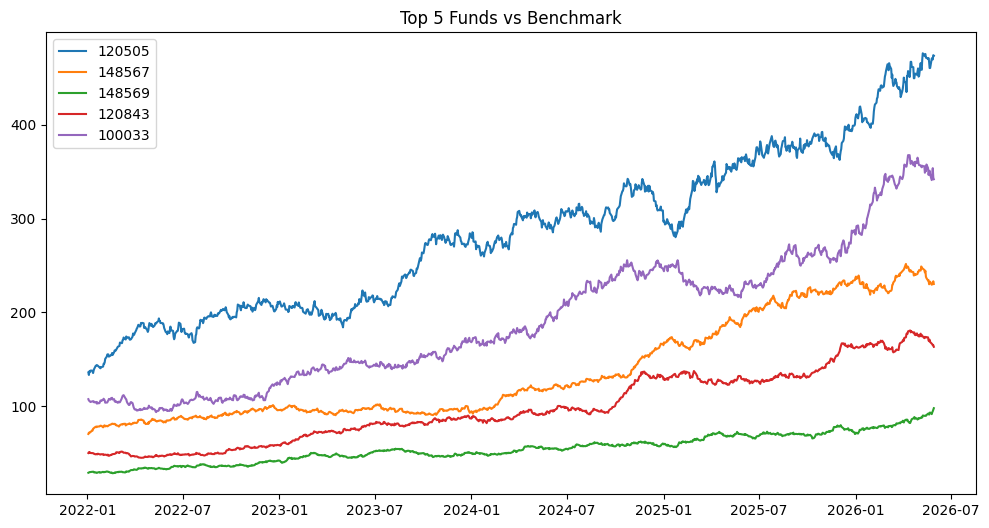

In [19]:
plt.figure(figsize=(12,6))

for code in top5:

    df = nav[nav['amfi_code'] == code]

    plt.plot(df['date'], df['nav'], label=str(code))

plt.legend()

plt.title("Top 5 Funds vs Benchmark")

plt.show()

In [20]:
plt.savefig("../reports/benchmark_comparison.png")

<Figure size 640x480 with 0 Axes>

## Insight 1
Funds with higher Sharpe ratios delivered more stable risk-adjusted returns.